# Part II: Understanding the basics of API requests 

**API (Application Programming Interface)** allows users to remotely access data. An API acts as an intermediary between you and the data server you are trying to access. Most applications you use to access real-time information (e.g. weather applications, stock exchanges, live airplane flight paths) rely on APIs to allow fast data exchanges over the internet. In some cases, going to the data source website and downloading a chunk of data may be simpler for one-time use cases, but programmatically accessing data through URLs is critical to monitor live data. In this example you will learn how to use API access to visualize real-time data from cabled observatories near Bamfield Marine Science Centre. 

**An API protocol consists of:**
1. Client Request: Create a specific query URL for the data you are interested in. Query input parameters may specify time ranges, geolocations, sensor IDs, essential ocean variable keywords.
2. Authentification and Security: You may need to provide user credentials to gain access to the database you are querying. To complete this example, you will need to register for an Ocean Networks Canada Oceans 3.0 account. Click [here](https://data.oceannetworks.ca/Registration) to register.
3. Processing: The API will use your query to return a subselection of data stored in the database based on your query filters.
4. Data formatting and Response: The requested data will be returned in JSON, XML, or Protocol Buffer structures. These formats are not very human readable.
5. Application Integration: Convert data from returned structure to human readable formats. Process or visualize data.

*Note: ONC's API Client Libraries complete steps 3 and 4 above for you.* 

**Client Libraries** are colections of pre-written, user-friendly functions designed specifically to interact with a particular API. **Importantly, client libraries are tailored to specific programming languages** (for example, ONC provides separate client libraries for Python, MATLAB). Instead of forcing you to write complex web requests from scratch, handle security headers, or manually parse messy JSON responses, the client library performs these API calls for you behind the scenes. It takes your simple inputs (like a location and date) and returns clean, ready-to-use data! The onc python client library has already been configured in our environments <br>

ONC provides a detailed API overview and guide to accessing their data [here](https://oceannetworkscanada.github.io/Oceans3.0-API/Home.html). 

In [32]:
import os
from dotenv import load_dotenv
from onc import ONC
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean

## Copy your ONC token
 To access ONC data through the API, you will need a unique token to authenticate your API request. 
1. Login to your [Oceans 3.0](https://data.oceannetworks.ca/Login?service=https://data.oceannetworks.ca) account
2. Navigate in the top bar to 'Profile'
3. Click the web services API tab
4. Copy Token and past in the code below <>

   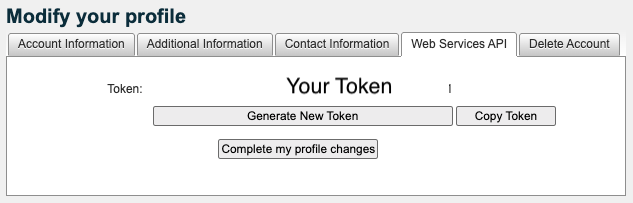

In [6]:
# Initialize the ONC client
token = '2bc9939e-d776-41ff-abe3-3cf7b0b465d1' # replace xxx with your unique token
onc = ONC(token)

### Finding Your Filters with the ONC OpenAPI Tool
You can't write a query if you don't know the exact location and device codes the database uses! To find these, ONC provides an interactive [OpenAPI interface](https://data.oceannetworks.ca/OpenAPI). 

**How to use it as a reference:**
1. **Log in:** Make sure you are logged into your Oceans 3.0 account in your browser. The OpenAPI tool automatically links to your active session and API token.
2. **Navigate:** Go to the [ONC OpenAPI page](https://data.oceannetworks.ca/OpenAPI). 
3. **Select an Endpoint:** Click on the specific endpoint you want to search. For example, click on `GET /locations` if you need to find a location code, or `GET /properties` if you need to look up a specific seawater variable.
4. **Test it out:** Click the **"Try it out"** button. You can enter plain-text search parameters (like typing "Folger" in the `locationName` box) or leave the filters blank to retrieve a broader list.
5. **Execute & Review:** Click **"Execute"**. Scroll down to the "Response body" block to see the JSON data returned by the server. Look through this output to find the exact `locationCode` (like `FGPPN`) or `deviceCategoryCode` you need to plug into your Python script.

We will walk through an example of using python commands to find the filters we need, but you can return to the OpenAPI interface when you want to rewrite your own queries. See some useful onc python commands below. 

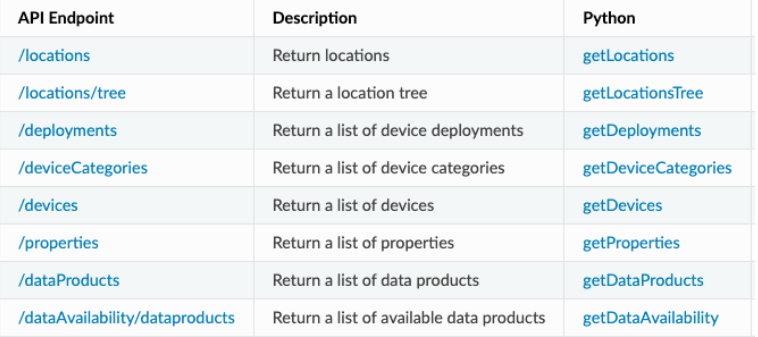

### Finding all ONC assets within a given geographic boundary

BMSC, the Barkley Sound region and surrounding offshore areas are shown below. Use the map to set Lat and Lon boundaries for an ONC instrument query
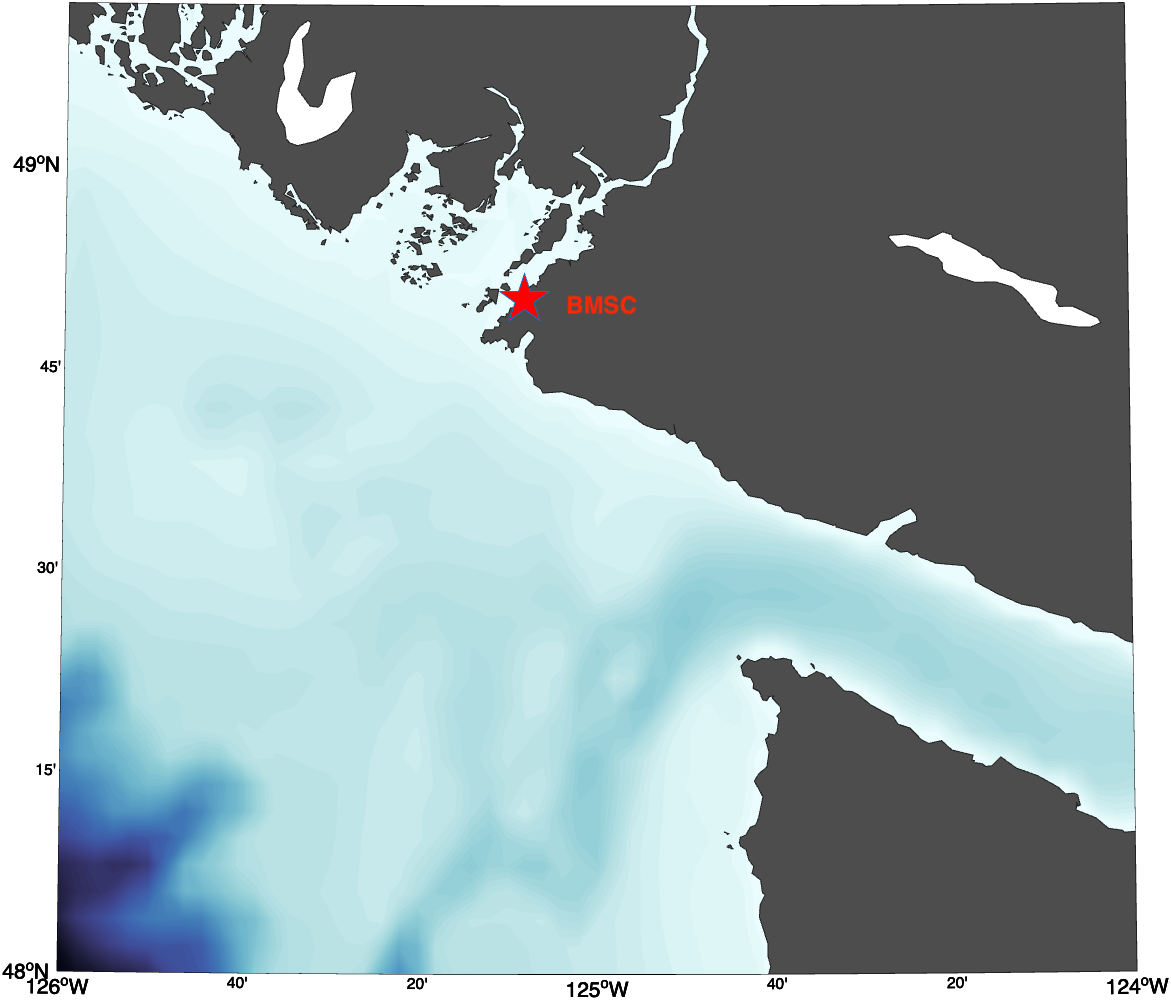

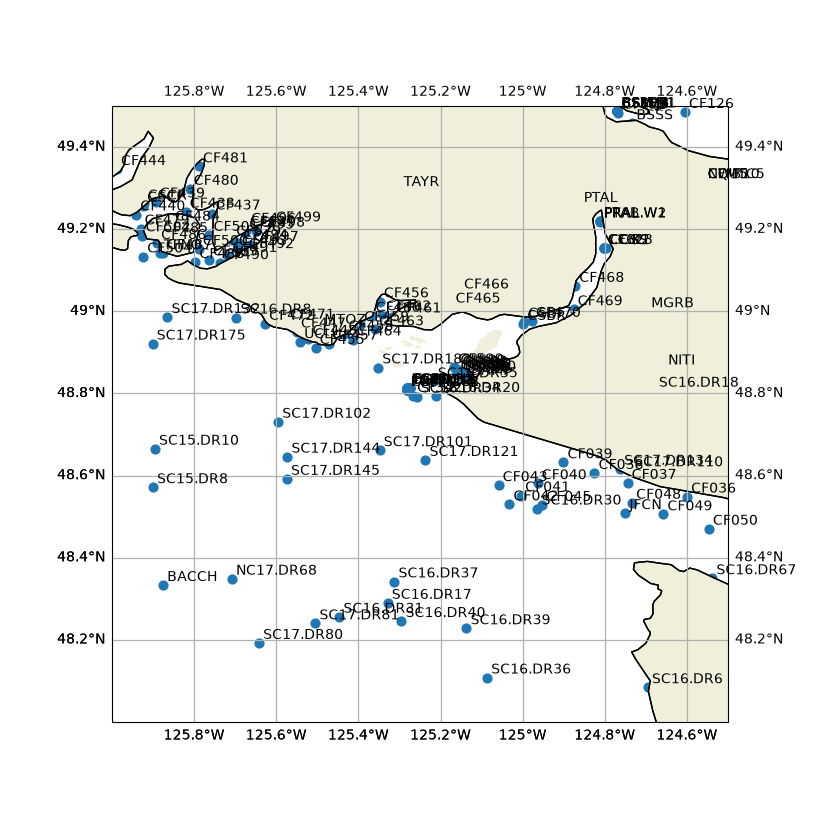

In [46]:
# Filter by lat x lon bounding boxes

# Define bounding box
minLat = 48 # Replace xxx with lat x lon boundaries of choice
maxLat = 49.5
minLon = -126
maxLon = -124.5

params = {'includeParents': True,}

locations = onc.getLocations(params)
df_locations = pd.DataFrame(locations)

# Keep locations within bounding box
df_subset = df_locations[
    (df_locations['lat'] > minLat) &
    (df_locations['lat'] < maxLat) &
    (df_locations['lon'] > minLon) &
    (df_locations['lon'] < maxLon)
]
# plot device locations with their codes
fig, ax = plt.subplots(
    figsize=(8, 8),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Label points with locationCodes
for _, row in df_subset.iterrows():
    ax.text(
        row['lon'] + 0.01,
        row['lat'] + 0.01,
        row['locationCode'],
        transform=ccrs.PlateCarree()
    )

ax.set_extent([
    minLon,
    maxLon,
    minLat,
    maxLat
])

ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.gridlines(draw_labels=True)

sc = ax.scatter(df_subset['lon'],df_subset['lat'],s=40,transform=ccrs.PlateCarree())

# Map features
ax.add_feature(cfeature.LAND, zorder=1)
ax.add_feature(cfeature.COASTLINE, zorder=2)

# Lat/lon grid
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False

plt.show()

### Narrowing in....
As you can see, ONC has deployed many devices in this area. However, not all of these devices are going to be useful, many of them are single CTD casts. Some are ancillary equipment, e.g. a light that connects to an underwater camera. 

In the next section you will filter for devices that *continuously* measure a property of interest (i.e. not a single CTD cast) and have collected data in the past week

ONC OpenAPI enables filtering locations according to the properties they measure, defined in controlled vocabulary terms, or `cvTerms`. 

#### A brief note on `cvTerms`
In oceanography, different groups might use different names for the same property (e.g., "Chlorophyll", "Chl_a", "chlorophyll_concentration"). A Controlled Vocabulary acts as a standardized, globally agreed-upon dictionary for these scientific terms. 

Inside the `cvTerm` data, you will often find:
* **`uom`**: The standardized **Unit of Measure**.
* **`uri`**: A **Uniform Resource Identifier** (a web link) pointing to the official, machine-readable definition of that term or unit in a global registry, such as the [NERC Vocabulary Server (NVS)](https://vocab.nerc.ac.uk/).

**Why does this matter?** This is a key part of **FAIR data principles** (Findable, Accessible, Interoperable, Reusable). By linking local data names to global standards like NERC, databases like ONC and Hakai can accurately communicate and be compared without any guesswork!

*(This will likely come up again in the reproducable workflows workshop later this week)*

see some useful property `cvTerms` you can filter by 

| propertyName           | propertyCode cvTerm   |    uom   |
|------------------------|-----------------------|----------|
| sea water temperature  | seawatertemperature   |   K      |
| salinity     | salinity  | psu  |
| conductivity  | conductivity   |   S/m  |
| colored dissolved organic matter  | cdom   | ppb|
| Chlorophyll a | chlorophyll   |    ug/L  |
| co2 partial pressure | co2partialpressure   | pCO2 uatm |
| density | density  | kg/m3 |
| nitrate concnetration | nitrateconcentration | umol/L |
| dissolved oxygen concentration | oxygen | ml/L |
| pH   |  ph  | pH  |
| turbidity  | turbidityntu  | NTU  |


18 chlorophyll detected
74 seawatertemperature detected
2 ph detected


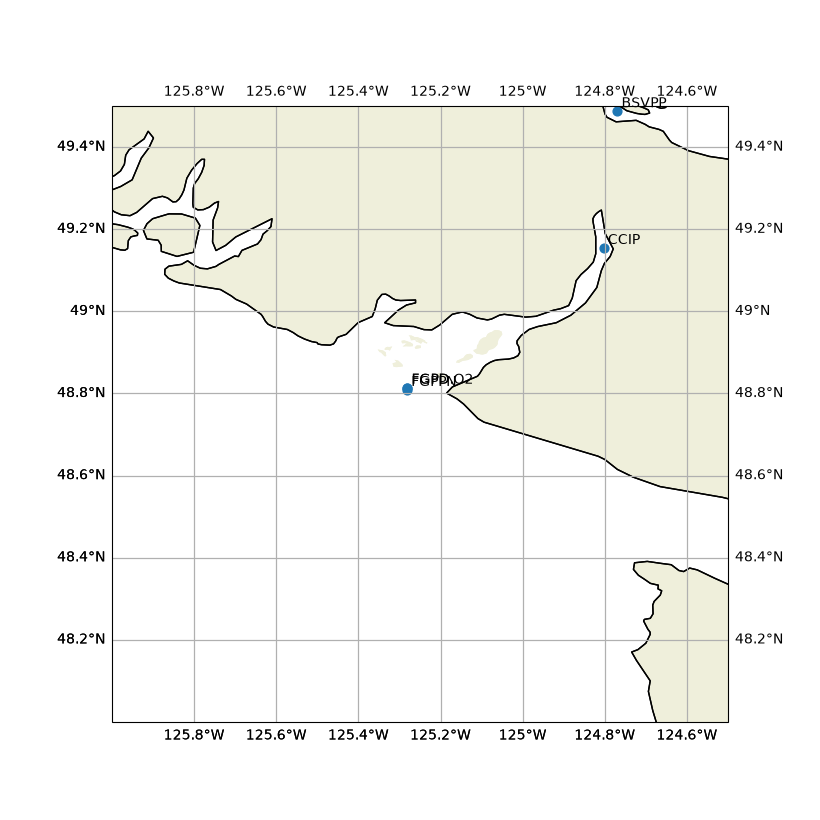

In [131]:
# Filtering for devices measuring properties of choice

propertyCodeWanted = ['chlorophyll',
                      'seawatertemperature',
                      'ph']                 # Replace xxxx with property code of interest

parentLocationCode = 'PAC' 

# Filtering for recent data
from datetime import datetime, timedelta, timezone
# Set our time filter to retrieve recent data.
# We'll use ISO 8601 format 

dt_recent = datetime.now(timezone.utc) - timedelta(days=7) # Update number of days for a longer or shorter time series
dateFrom = dt_recent.strftime('%Y-%m-%dT%H:%M:%S.000Z')

# PAC location parent includes all long-term monitoring platforms deployed in the Pacific. one time deployments casts are under the MOBP parent location (mobile platform)

# Store results here
results = [] 

for propCode in propertyCodeWanted: 
    params = {'locationCode': parentLocationCode,
              'propertyCode': propCode,
              'dateFrom': dateFrom,
              'includeChildren': True}
    try: 
        response = onc.getLocations(params)
        response_df = pd.DataFrame(response)
        response_df['propertyCode'] = propCode
        
        # Keep locations within bounding box
        responseSubset_df = response_df[
            (response_df['lat'] > minLat) &
            (response_df['lat'] < maxLat) &
            (response_df['lon'] > minLon) &
            (response_df['lon'] < maxLon)]
        
        # Save compiled data in a new data frame
        results.append(responseSubset_df)

        print(f"{len(response_df)} {propCode} detected")

    except Exception as e:
        print(f"no {propCode} detected")
        continue 

# Combine results 
filteredSensors = pd.concat(results, ignore_index=True)
filteredSensors = (filteredSensors.groupby('locationCode', as_index=False)
    .agg({'locationName': 'first',
        'lat': 'first',
        'lon': 'first',
        'depth': 'first',
        'propertyCode': lambda x: ','.join(x)}))

# Remove single CTD casts. # Note this step required apriori knowledge of ONC naming schemes for ctd casts
CF = filteredSensors['locationCode'].str.startswith('CF', na=False)
Patrol = filteredSensors['locationName'].str.contains('Patrol',na=False)

filteredSensors = filteredSensors[~(CF | Patrol)].copy()
        
# Replot the narrowed down device list 
fig, ax = plt.subplots(
    figsize=(8, 8),
    subplot_kw={'projection': ccrs.PlateCarree()})

# Label points with locationCodes
for _, row in filteredSensors.iterrows():
    ax.text(
        row['lon'] + 0.01,
        row['lat'] + 0.01,
        row['locationCode'],
        transform=ccrs.PlateCarree())

ax.set_extent([
    minLon,
    maxLon,
    minLat,
    maxLat
])

ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.gridlines(draw_labels=True)

sc = ax.scatter(filteredSensors['lon'],filteredSensors['lat'],s=40,transform=ccrs.PlateCarree())

# Map features
ax.add_feature(cfeature.LAND, zorder=1)
ax.add_feature(cfeature.COASTLINE, zorder=2)

# Lat/lon grid
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False

plt.show()

We are seeing overlap where there are multiple sensors deployed at different depths. Let's look at the table of locations and select a single location to investigate more closely

In [132]:
display(filteredSensors)

,locationCode,locationName,lat,lon,depth,propertyCode
0,BSVPP,Profiling Instrument Package,49.486885,-124.769333,34.53,"chlorophyll,seawatertemperature,ph"
1,CCIP,China Creek Underwater Network,49.153883,-124.802550,113.00,"chlorophyll,seawatertemperature"
6,FGPD,Folger Deep,48.813866,-125.280554,95.00,seawatertemperature
7,FGPD.O2,Oxygen Sensor SBE63,48.813762,-125.280777,96.00,seawatertemperature
8,FGPPN,Folger Pinnacle,48.808292,-125.281500,25.00,seawatertemperature


### Discover all the properties measured at site of choice

Select one of the filtered locationCodes to explore more deeply. See what other properties it measures besides the propertyCode you filtered for. 

In [133]:
locationCode = 'CCIP' # xxxxx. Replace with one of the locationCodes returned above 

# Use the filters above to view what seawater properties are measured and availability for Folger Pinnacle.
params = {'locationCode': locationCode
          }
properties = onc.getProperties(params)

# Convert to a DataFrame for clean formatting
df_properties = pd.DataFrame(properties)

# Display just the first 10 rows
print(f"Showing properties available at this location.")
display(df_properties)

Showing properties available at this location.


,cvTerm,description,hasDeviceData,hasPropertyData,propertyCode,propertyName,uom
0,"{'property': [], 'uom': []}",Amperage,True,False,amperage,Amperage,A
1,"{'property': [], 'uom': [{'uri': 'http://vocab...",Aperture of Camera Lens,True,False,aperture,Aperture,%
2,"{'property': [], 'uom': [{'uri': 'http://vocab...",Battery Charge,True,False,batterycharge,Battery Charge,%
3,"{'property': [], 'uom': []}",Biofouling Prevention,True,False,biofoulingprevention,Biofouling Prevention,ON/OFF
4,"{'property': [], 'uom': [{'uri': 'http://vocab...",Light Brightness,True,False,brightness,Brightness,%
5,"{'property': [], 'uom': [{'uri': 'http://vocab...",Chlorophyll,True,True,chlorophyll,Chlorophyll,ug/l
6,"{'property': [], 'uom': [{'uri': 'http://vocab...",Conductivity: siemens per metre,True,True,conductivity,Conductivity,S/m
7,"{'property': [], 'uom': [{'uri': 'http://vocab...",Light Contrast,True,False,contrast,Contrast,%
8,"{'property': [], 'uom': []}",Defog: Remove fog effect from image,True,False,defog,Defog,ON/OFF
9,"{'property': [], 'uom': [{'uri': 'http://vocab...",Defog Effect: Amount of defog effect,True,False,defog_effect,Defog Effect,%


### Discover how your property of interest is measured
Get a device category for the site and property you are examining

In [134]:
propertyCode = 'seawatertemperature' # <- xxxx. input any of the available properties returned 
params = {'locationCode': locationCode, 'propertyCode': propertyCode}

devices = onc.getDeviceCategories(params) # <- ONC requires a device category code to be specified
display(pd.DataFrame(devices))

,cvTerm,description,deviceCategoryCode,deviceCategoryName,hasDeviceData,longDescription
0,{'deviceCategory': [{'uri': 'http://vocab.nerc...,Conductivity Temperature (and Depth Sensor),CTD,Conductivity Temperature Depth,True,Conductivity Temperature Depth (CTD) is an in...
1,{'deviceCategory': [{'uri': 'http://vocab.nerc...,Oxygen Sensor,OXYSENSOR,Oxygen Sensor,True,Oxygen sensors measure dissolved oxygen conce...


## Retrieving near real-time data

In [144]:
# Refine your search filters
deviceCategoryCode = 'CTD' # Update xxx from table above

dt_recent = datetime.now(timezone.utc) - timedelta(days=1) # Update number of days for a longer or shorter time series
dateFrom = dt_recent.strftime('%Y-%m-%dT%H:%M:%S.000Z')

params = {
    'locationCode': locationCode,
    'deviceCategoryCode': deviceCategoryCode,
    'propertyCode': propertyCode,
    'dateFrom': dateFrom}

# Call method
result = onc.getDirectByLocation(params) # Dictionary containing data and metadata
citation = pd.DataFrame(result['citations'])
display(citation.iloc[0]) # Display the full citation for this data, including how to properly credit ONC when using this data in your work.

citation          Ocean Networks Canada Society. 2025. China Cre...
doi                   10.34943/d6639a05-4813-4651-8298-dbae86ba4b65
landingPageUrl    https://doi.org/10.34943/d6639a05-4813-4651-82...
queryPid                                                       None
Name: 0, dtype: object

In [145]:
# The Python library returns a dictionary where sensor data is in a list
sensor_data = result['sensorData'][0]
print(f"Sensor data for {propertyCode} at {locationCode} from {dateFrom} to {dateTo}:")
display(sensor_data)

units = sensor_data['unitOfMeasure']

# The API Client Library uses code to format your filters into a specialized URL
# print the URL
print(f"Query URL: {result['queryUrl']}")

Sensor data for seawatertemperature at CCIP from 2026-08-18T23:03:44.000Z to 2026-08-19T22:43:09.000Z:


{'actualSamples': 86401,
 'data': {'qaqcFlags': [1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,


Query URL: https://data.oceannetworks.ca/api/scalardata/location?locationCode=CCIP&deviceCategoryCode=CTD&propertyCode=seawatertemperature&dateFrom=2026-08-18T23%3A03%3A44.000Z&token=2bc9939e-d776-41ff-abe3-3cf7b0b465d1


## Data Visualization

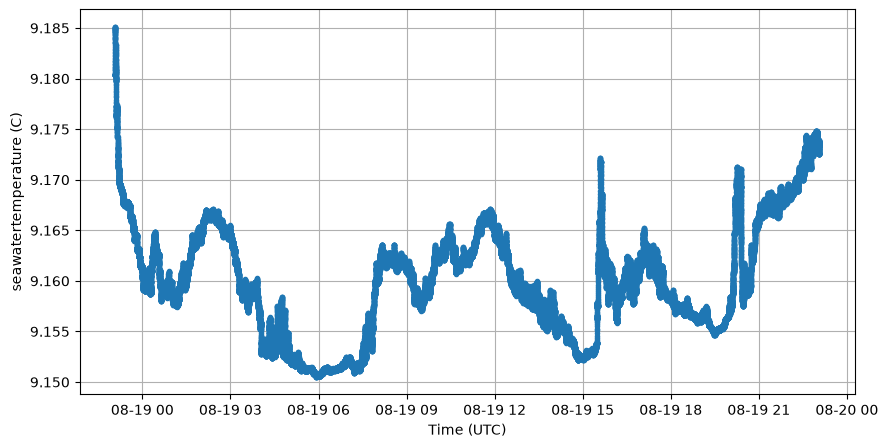

In [146]:
import matplotlib.pyplot as plt

# Extract timestamps and values
ts = sensor_data['data']['sampleTimes']
measuredValues = sensor_data['data']['values']

# Convert ISO8601 date strings to datetime objects for plotting
sampleTimes_dt = pd.to_datetime(ts)

# Plot the measured values against the datetime
plt.figure(figsize=(10, 5))
plt.plot(sampleTimes_dt, measuredValues, '.')
plt.xlabel('Time (UTC)')
plt.ylabel(f"{propertyCode} ({units})")
plt.grid(True)
plt.show()

## Retrieve only the most recent data
In the example above, we programmatically set our time range to filter for recent data defined by `dateFrom`. We can also filter for the most recent data entry available by setting the 'getLatest' boolean filter to true.

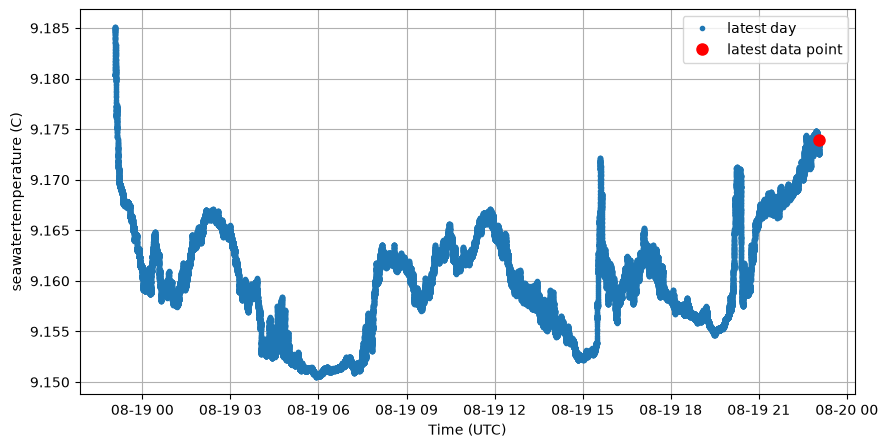

In [147]:
params_latest = {
    'locationCode': locationCode,
    'deviceCategoryCode': deviceCategoryCode,
    'propertyCode': propertyCode,
    'rowLimit': 1,      # <- Adjust the rowLimit to see further back in time
    'getLatest': True
}

resultLatest = onc.getDirectByLocation(params_latest)
latest_data = resultLatest['sensorData'][0]['data']

# Parse the latest datetime
latest_dt = pd.to_datetime(latest_data['sampleTimes'])
latest_val = latest_data['values']

# Update the plot with the latest data retrieved 
plt.figure(figsize=(10, 5))
plt.plot(sampleTimes_dt, measuredValues, '.', label='latest day')
plt.plot(latest_dt, latest_val, 'ro', linewidth=2, markersize=8, label='latest data point')
plt.xlabel('Time (UTC)')
plt.ylabel(f"{propertyCode} ({units})")
plt.grid(True)
plt.legend()
plt.show()

## Downloading longer data frames 
This example showed a day's worth of data from yesterday to today. You may want to look at a longer range. If you use the onc library `getDirectByLocation` supports an `allPages` parameter. When set to True, it will try to retrieve all the pages.

In [148]:
# 1. Define your filter parameter with a longer date range 

# Update to look at the previous year of data rather than the previous day.
dt_last_year = datetime.now(timezone.utc) - timedelta(days=360)
dateFromLong = dt_last_year.strftime('%Y-%m-%dT%H:%M:%S.000Z')

# By default, ONC provides clean data avg'd in 15min bins. 
# As we pull longer time series, we can modify our parameters with 'resamplePeriod' to retrieve data avg'd every day (86400 seconds), every 4hr (14400 seconds), or every 30min (1800 seconds), every 12hr (43200 seconds) etc. 
resample = 14400 # 4hr bins 
resampleType = 'avg'

paramsLongerRange = {
    'locationCode': locationCode,
    'propertyCode': propertyCode,
    'deviceCategoryCode': deviceCategoryCode,
    'dateFrom': dateFromLong,
    'dateTo': dateTo,
    'resamplePeriod': resample,
    'resampleType': resampleType
}

# Call methods in the onc library (Python uses allPages=True as an argument)
result_long = onc.getDirectByLocation(paramsLongerRange, allPages=True)
print(f"Query URL: {result_long['queryUrl']}")

Query URL: https://data.oceannetworks.ca/api/scalardata/location?locationCode=CCIP&propertyCode=seawatertemperature&deviceCategoryCode=CTD&dateFrom=2025-08-24T23%3A04%3A16.000Z&dateTo=2026-08-19T22%3A43%3A09.000Z&resamplePeriod=14400&resampleType=avg&token=2bc9939e-d776-41ff-abe3-3cf7b0b465d1


## Use onc.getDeployments to retrieve the full time series

In [149]:
# Probe the location and parameter properties to discover when instruments
# were deployed at the study site
deployments = onc.getDeployments({
    'locationCode': locationCode,
    'propertyCode': propertyCode,
    'deviceCategoryCode': deviceCategoryCode
})

# Extract deployment start times
deploymentsStart = [dep['begin'] for dep in deployments]

# Convert strings to datetime objects
dt_deploy = pd.to_datetime(deploymentsStart)

# Find the earliest deployment date
dataCollectionStart = dt_deploy.min()

# Convert earliest datetime back to ISO8601 format and update dateFrom
dateFromStart = dataCollectionStart.strftime('%Y-%m-%dT%H:%M:%S.000Z') 

paramsFull = {
    'locationCode': locationCode,
    'propertyCode': propertyCode,
    'deviceCategoryCode': deviceCategoryCode,
    'dateTo': dateTo,
    'dateFrom': dateFromStart,
    'resamplePeriod': resample,
    'resampleType': resampleType
}

# Call methods in the onc library
resultFull = onc.getDirectByLocation(paramsFull, allPages=True)

## Visualization for the full time series

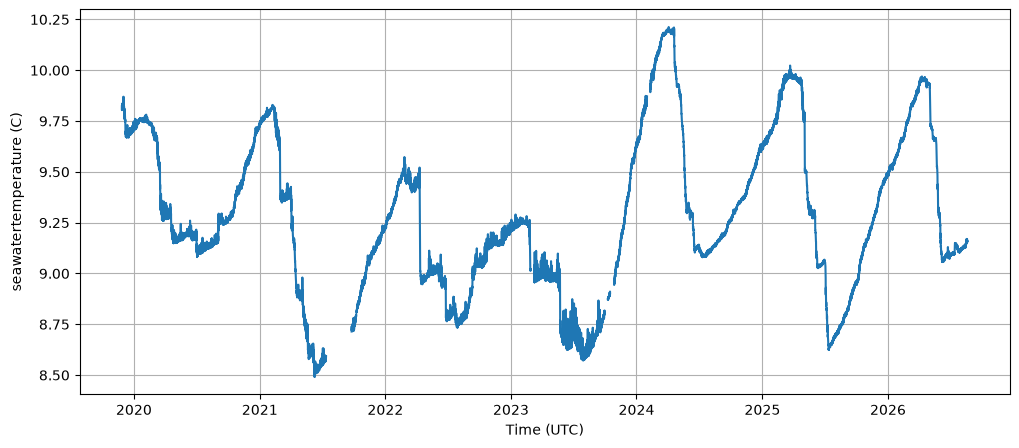

In [150]:
import numpy as np

sensor_data_full = resultFull['sensorData'][0]
sampleTimesFull_dt = pd.to_datetime(sensor_data_full['data']['sampleTimes'])
valuesFull = np.array(sensor_data_full['data']['values'])

# Plot the full time series
plt.figure(figsize=(12, 5))
plt.plot(sampleTimesFull_dt, valuesFull)
plt.xlabel('Time (UTC)')
plt.ylabel(f"{propertyCode} ({units})")
plt.grid(True)
plt.show()

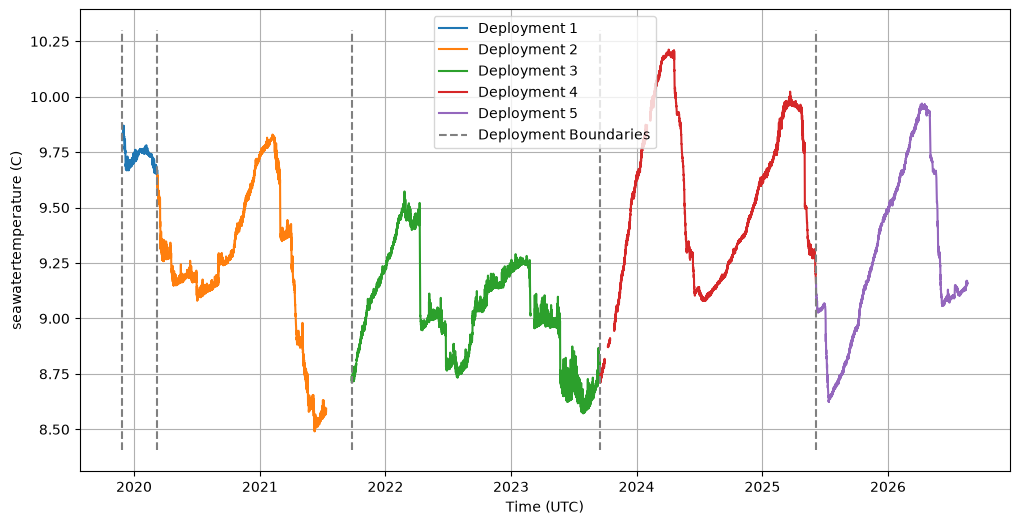

In [153]:
# Re-plot time series with segments colored between deployment change times

# Ensure arrays are sorted
sort_idx = np.argsort(sampleTimesFull_dt)
t = sampleTimesFull_dt[sort_idx]
v = valuesFull[sort_idx]

# Combine deployment datetimes with start and end bounds
deployTimes = np.sort(dt_deploy.values)
boundaries = np.append(deployTimes, t.values[-1])

nSeg = len(boundaries) - 1
colors = plt.colormaps.get_cmap('tab10')

plt.figure(figsize=(12, 6))

for k in range(nSeg):
    segStart = boundaries[k]
    segEnd = boundaries[k+1]
    idx = (t.values >= segStart) & (t.values <= segEnd)
    plt.plot(t[idx], v[idx], '-', color=colors(k), linewidth=1.5, label=f'Deployment {k+1}')

# Plot deployment markers as vertical dashed lines
yl = plt.gca().get_ylim()
for k, x in enumerate(deployTimes):
    label = 'Deployment Boundaries' if k == 0 else ""
    plt.plot([x, x], yl, '--', color='gray', label=label)

plt.xlabel('Time (UTC)')
plt.ylabel(f"{propertyCode} ({units})")
plt.grid(True)
plt.legend(loc='best')
plt.show()